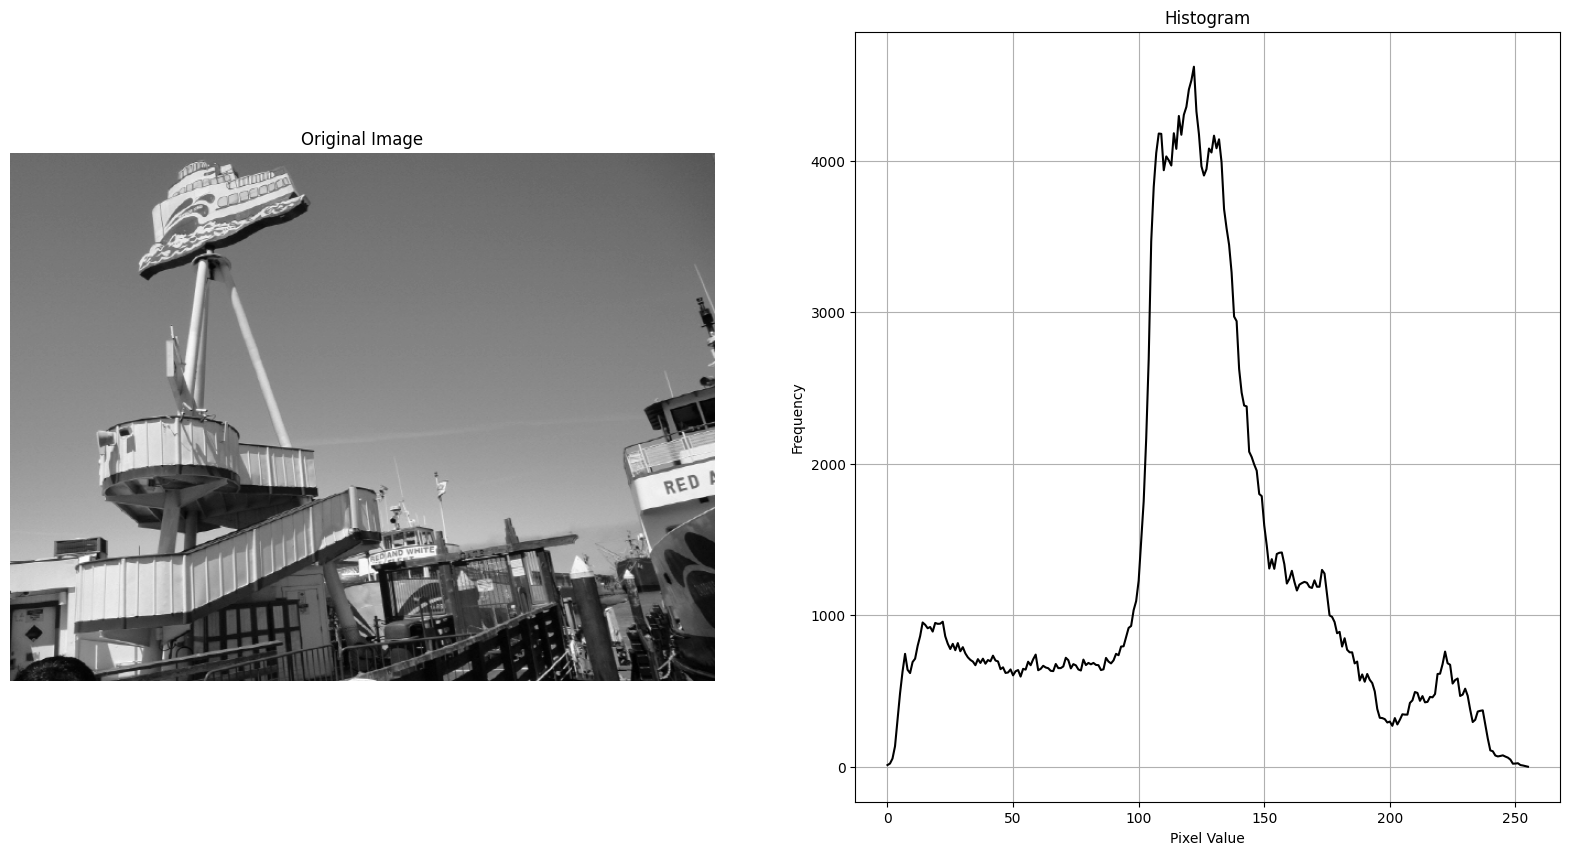

In [1]:
# 이미지 히스토그램 표시 (그레이 스케일)
import cv2
import numpy as np
from matplotlib import pyplot as plt

image = cv2.imread('../../sample/pier39.JPG', cv2.IMREAD_GRAYSCALE)
hist = cv2.calcHist([image], [0], None, [256], [0, 256])
plt.figure(figsize=(20, 10))

plt.subplot(121)
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(122)
plt.plot(hist, color='black')
plt.title('Histogram')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.grid(True)

plt.show()

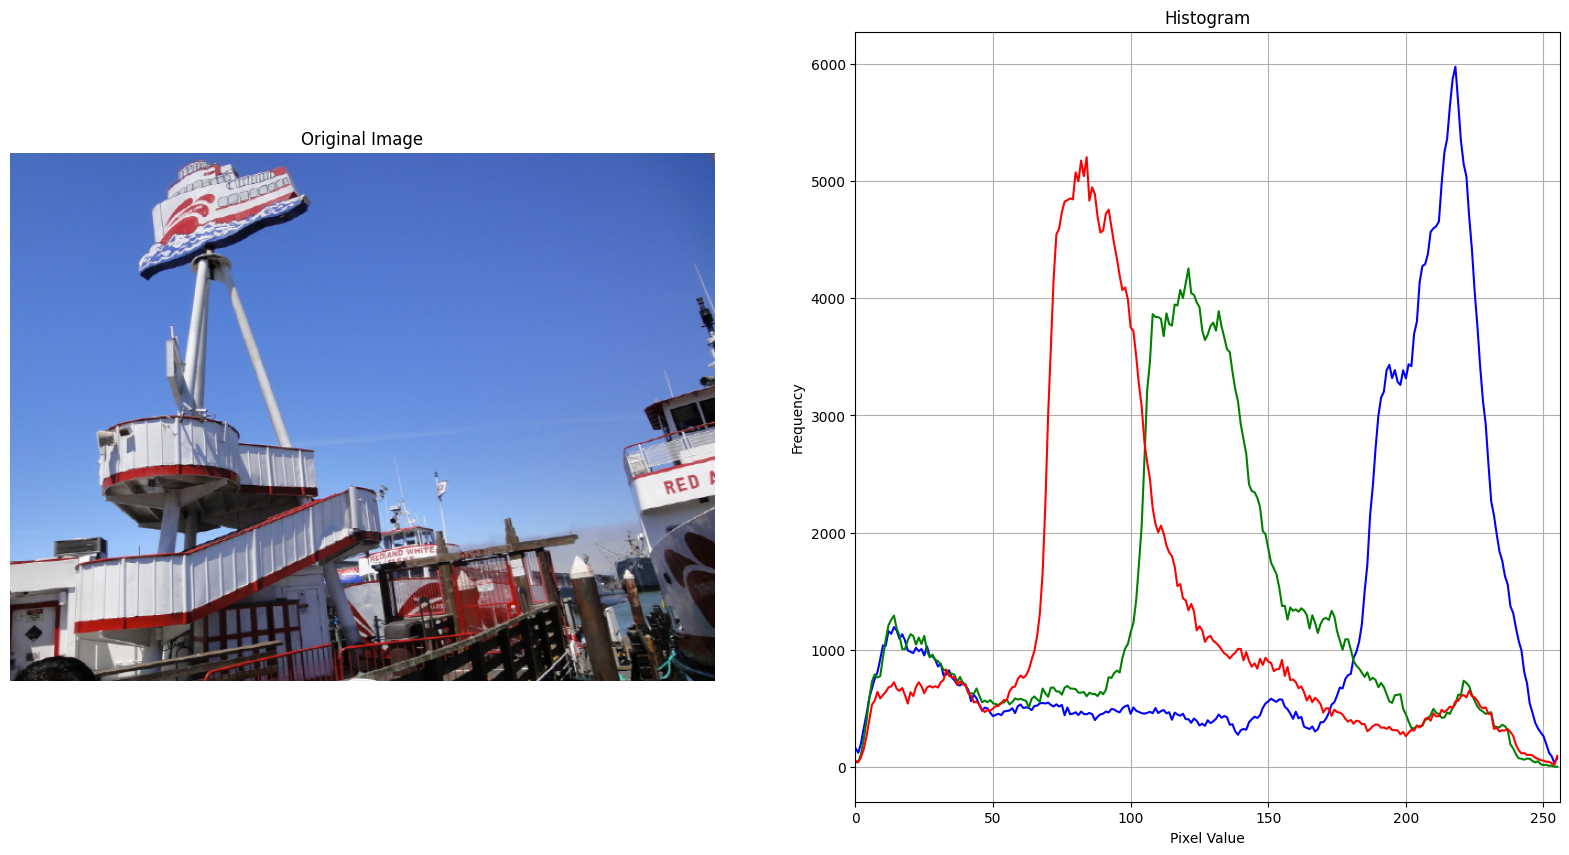

In [2]:
# 이미지 히스토그램 표시 (컬러 스케일)
import cv2
import numpy as np
from matplotlib import pyplot as plt

image = cv2.imread('../../sample/pier39.JPG')

channels = ('b', 'g', 'r')
colors = ('blue', 'green', 'red')
plt.figure(figsize=(20, 10))

plt.subplot(121)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(122)
for i, color in enumerate(colors):
    hist = cv2.calcHist([image], [i], None, [256], [0, 256])
    plt.plot(hist, color=color)
    plt.xlim([0, 256])
plt.title('Histogram')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

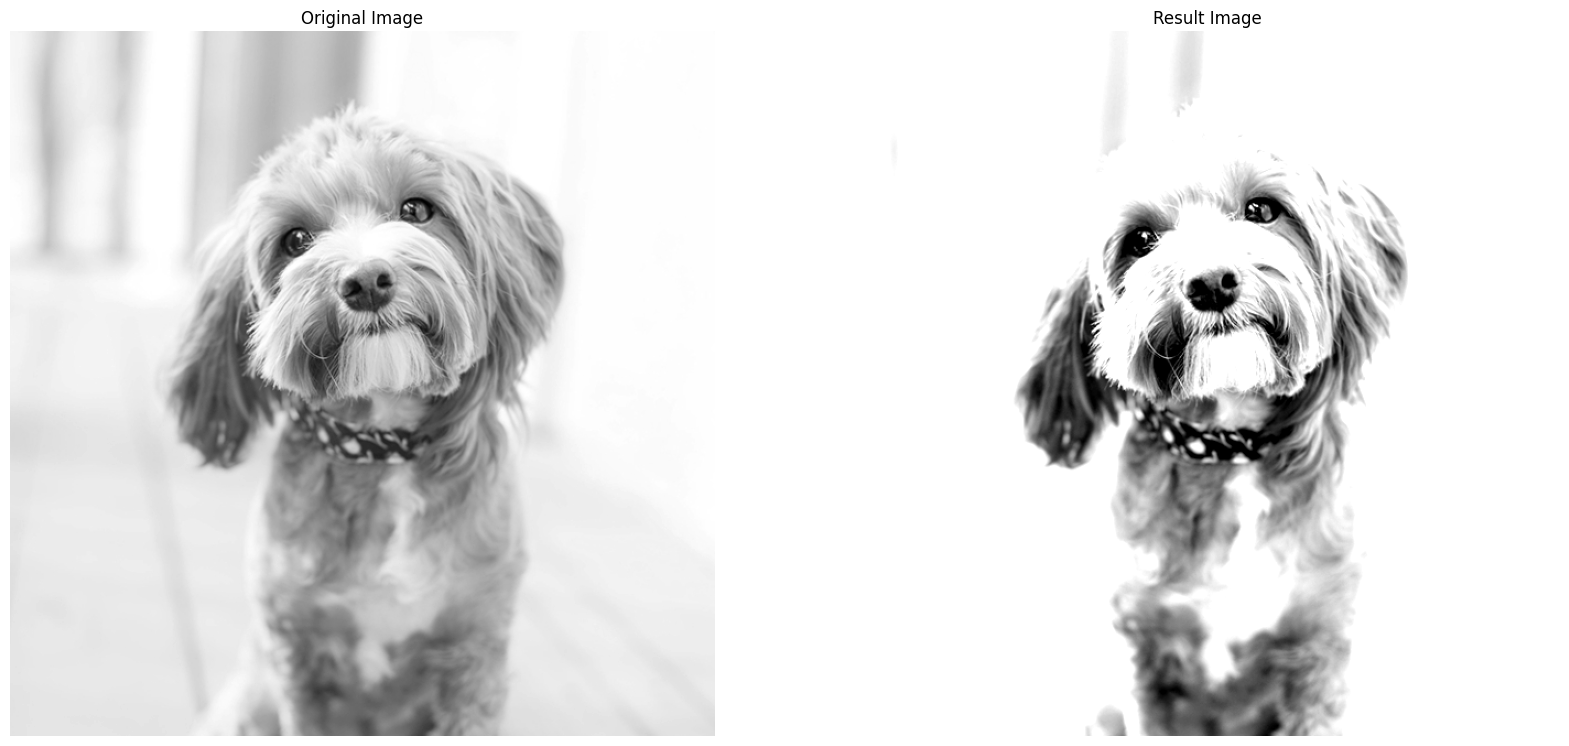

In [3]:
# 영상의 명암비 조정
import cv2
import numpy as np
from matplotlib import pyplot as plt

src = cv2.imread('../../sample/dog.jpg', cv2.IMREAD_GRAYSCALE)

alpha = 1.0
dst = np.clip((1+alpha)*src - 128*alpha, 0, 255).astype(np.uint8)

plt.figure(figsize=(20, 10))
plt.subplot(121)
plt.imshow(src, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(122)
plt.imshow(dst, cmap='gray')
plt.title('Result Image')
plt.axis('off')

plt.show()

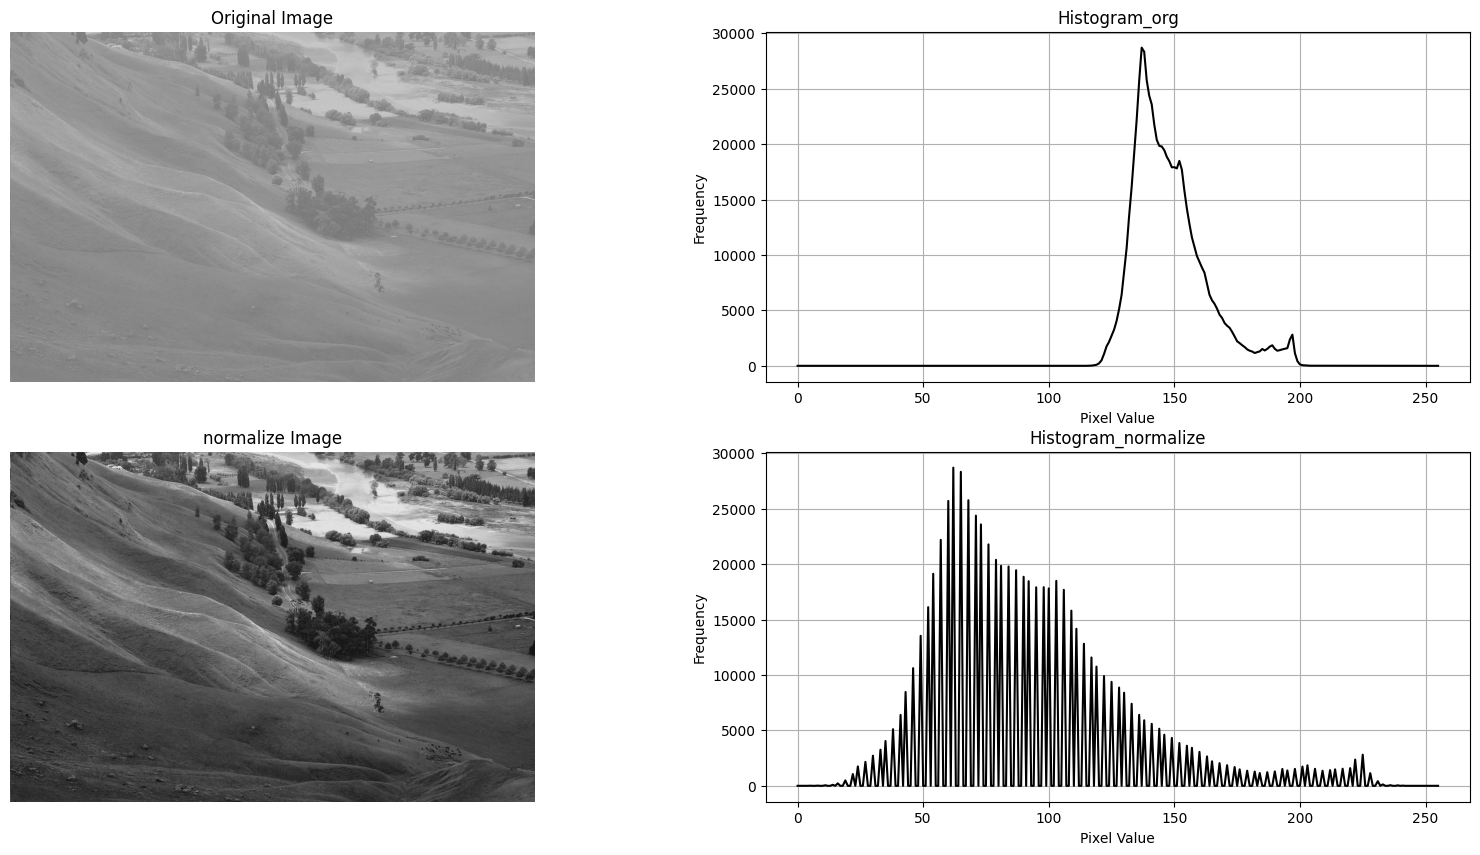

In [4]:
# 이미지 히스토그램 스트레칭 -> 일부 구간의 히스토그램을 전 구간에 나타내도록 하는 기법
import cv2
from matplotlib import pyplot as plt

src = cv2.imread('../../sample/Hawkes_Bay.jpg', cv2.IMREAD_GRAYSCALE)
dst = cv2.normalize(src, None, 0, 255, cv2.NORM_MINMAX)
hist_src = cv2.calcHist([src], [0], None, [256], [0, 256])
hist_dst = cv2.calcHist([dst], [0], None, [256], [0, 256])

plt.figure(figsize=(20, 10))

plt.subplot(221)
plt.imshow(cv2.cvtColor(src, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(222)
plt.plot(hist_src, color='black')
plt.title('Histogram_org')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.grid(True)

plt.subplot(223)
plt.imshow(dst, cmap='gray')
plt.title('normalize Image')
plt.axis('off')

plt.subplot(224)
plt.plot(hist_dst, color='black')
plt.title('Histogram_normalize')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.grid(True)

plt.show()

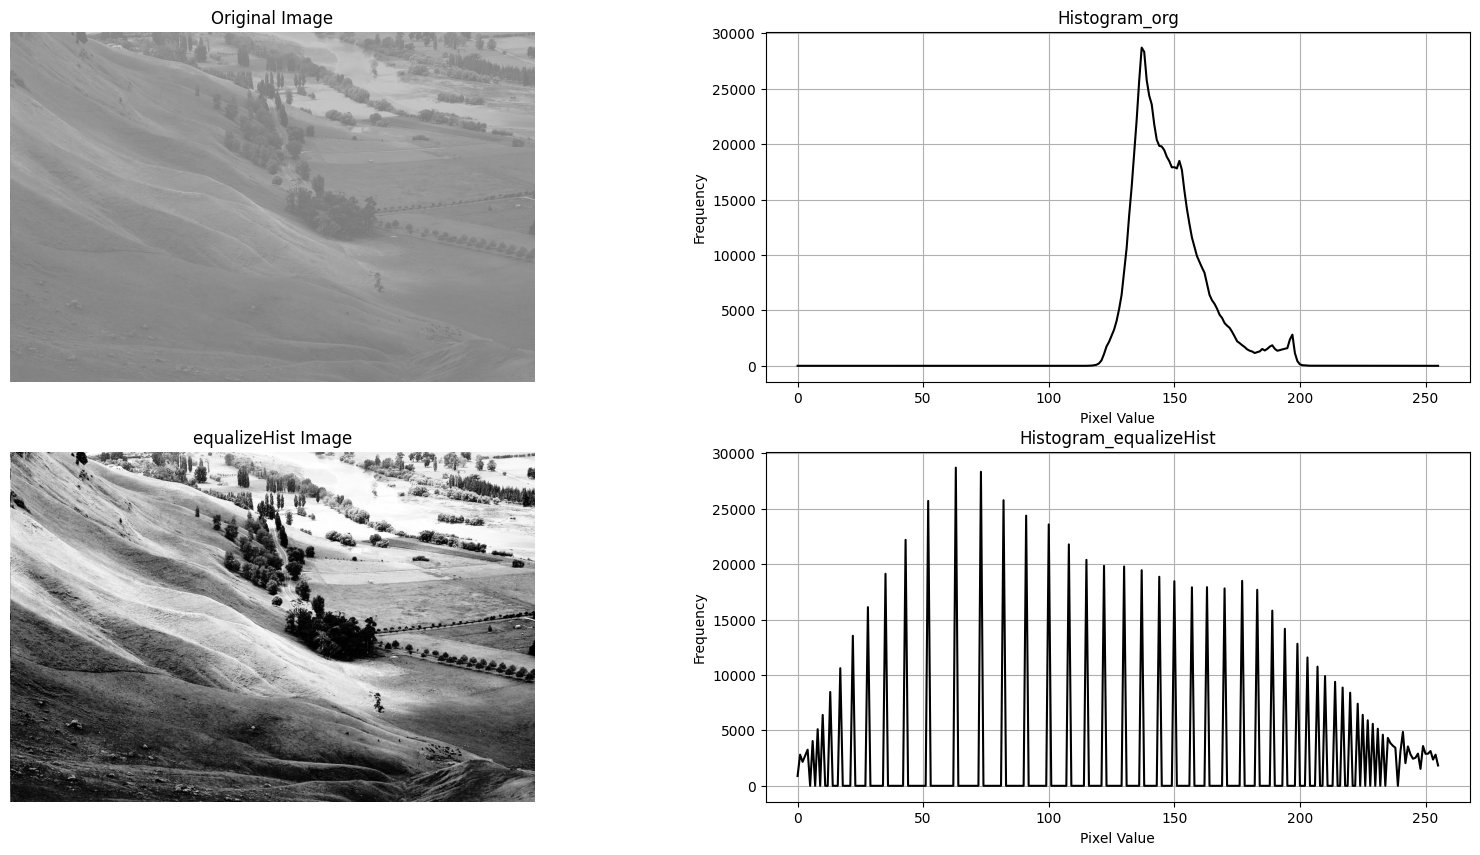

In [1]:
# 평활화 적용 -> 이때 스트레칭 먼저 진행 후(equalizeHist에 포함) 평활화 진행
import cv2
from matplotlib import pyplot as plt

src = cv2.imread('../../sample/Hawkes_Bay.jpg', cv2.IMREAD_GRAYSCALE)
dst = cv2.equalizeHist(src)
hist_src = cv2.calcHist([src], [0], None, [256], [0, 256])
hist_dst = cv2.calcHist([dst], [0], None, [256], [0, 256])

plt.figure(figsize=(20, 10))

plt.subplot(221)
plt.imshow(cv2.cvtColor(src, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(222)
plt.plot(hist_src, color='black')
plt.title('Histogram_org')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.grid(True)

plt.subplot(223)
plt.imshow(dst, cmap='gray')
plt.title('equalizeHist Image')
plt.axis('off')

plt.subplot(224)
plt.plot(hist_dst, color='black')
plt.title('Histogram_equalizeHist')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.grid(True)

plt.show()

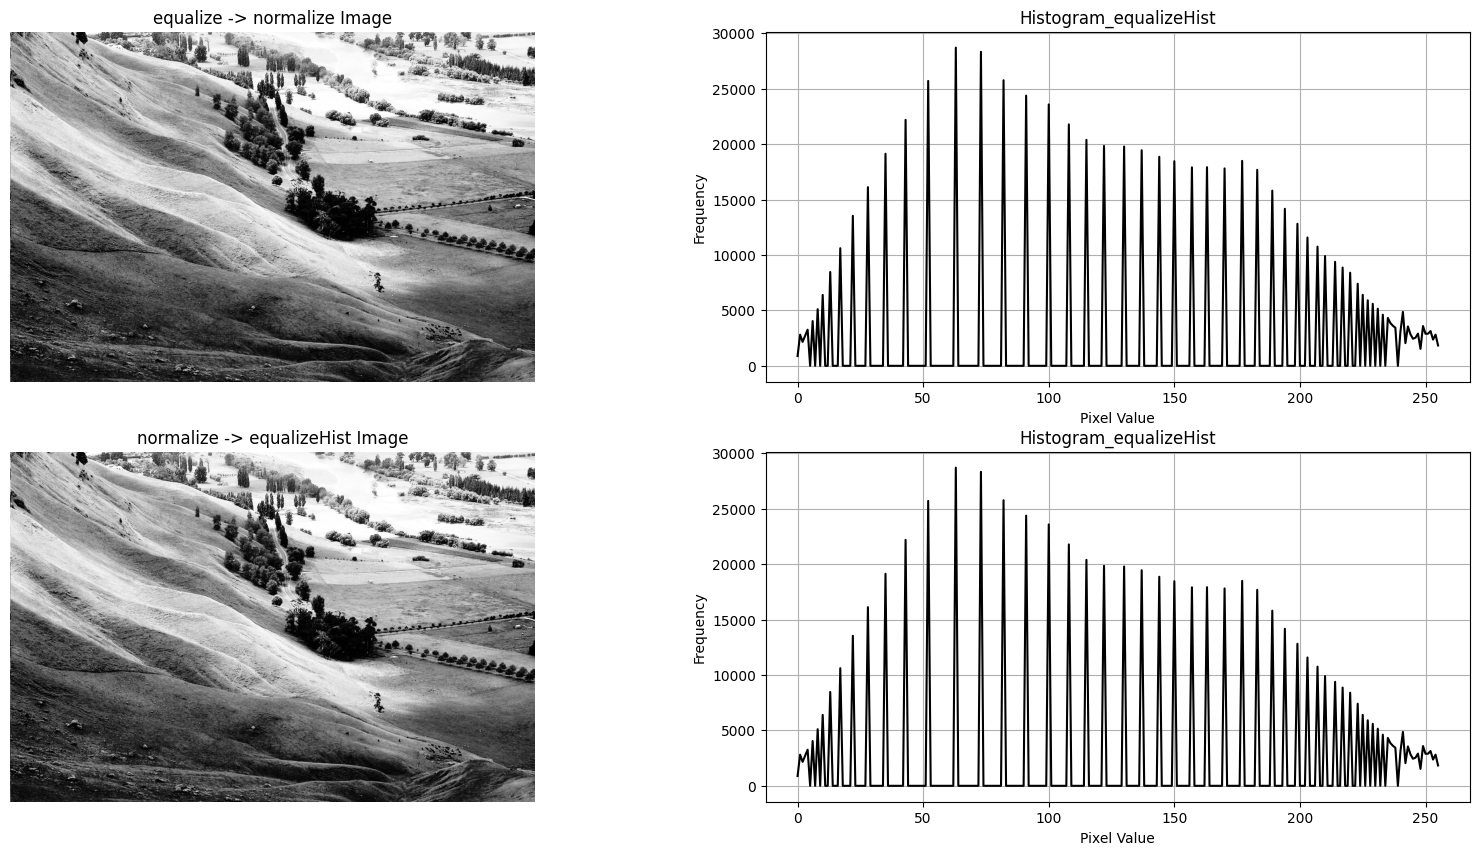

In [6]:
import cv2
from matplotlib import pyplot as plt

image = cv2.imread('../../sample/Hawkes_Bay.jpg', cv2.IMREAD_GRAYSCALE)

# 실습1 - 평활화 후 스트레칭 작업
src1 = cv2.equalizeHist(image)
dst1 = cv2.normalize(src1, None, 0, 255, cv2.NORM_MINMAX)
hist_src1 = cv2.calcHist([src1], [0], None, [256], [0, 256])
hist_dst1 = cv2.calcHist([dst1], [0], None, [256], [0, 256])

plt.figure(figsize=(20, 10))

plt.subplot(221)
plt.imshow(dst1, cmap='gray')
plt.title('equalize -> normalize Image')
plt.axis('off')

plt.subplot(222)
plt.plot(hist_dst1, color='black')
plt.title('Histogram_equalizeHist')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.grid(True)

# 실습2 - 스트레칭 후 평활화 작업
src2 = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX)
dst2 = cv2.equalizeHist(src2)
hist_src2 = cv2.calcHist([src2], [0], None, [256], [0, 256])
hist_dst2 = cv2.calcHist([dst2], [0], None, [256], [0, 256])

plt.subplot(223)
plt.imshow(dst2, cmap='gray')
plt.title('normalize -> equalizeHist Image')
plt.axis('off')

plt.subplot(224)
plt.plot(hist_dst1, color='black')
plt.title('Histogram_equalizeHist')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.grid(True)

plt.show()